<a href="https://colab.research.google.com/github/jonathancagua/audio/blob/main/audio_cuanti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Este conjunto de datos recopila cantos de cinco especies de aves (Cucarachero de Bewick, Cardenal Norteño, Robin Americano, Gorrión Melódico y Cenzontle Norteño) con el objetivo de entrenar modelos de identificación a partir de grabaciones de 3 segundos. Los audios, extraídos de la plataforma xeno-canto, están estandarizados en formato wav (22050 Hz, mono) y se incluyen en un archivo CSV con metadatos asociados. Puede explorar el conjunto de datos completo en [Kaggle](
https://www.kaggle.com/datasets/vinayshanbhag/bird-song-data-set)

In [1]:
import pandas as pd
import numpy as np
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt
import librosa.display
from sklearn.model_selection import train_test_split
import keras
from keras import Model, Input
from keras.layers import Conv1D, Flatten, Dense, Dropout, SpatialDropout1D, GlobalAveragePooling1D
from keras.optimizers import Adam
from keras.optimizers.schedules import ExponentialDecay
from keras.losses import SparseCategoricalCrossentropy
from keras.metrics import SparseCategoricalAccuracy
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, roc_auc_score
from keras.callbacks import TensorBoard, ModelCheckpoint
import seaborn as sns

In [2]:
!pip install kaggle

In [3]:
!kaggle datasets download -d vinayshanbhag/bird-song-data-set --unzip -p ./bird-data



Dataset URL: https://www.kaggle.com/datasets/vinayshanbhag/bird-song-data-set
License(s): other
100% 2.09G/2.09G [02:01<00:00, 18.5MB/s]



In [4]:
import os

DATA_DIR = "/content/bird-data"
metadata = pd.read_csv(f"{DATA_DIR}/bird_songs_metadata.csv")

label_dict = {
    'bewickii': 0, 'polyglottos': 1, 'migratorius': 2,
    'melodia': 3, 'cardinalis': 4
}
bird_labels = metadata['species'].map(label_dict).values

bird_filepaths = (DATA_DIR + "/wavfiles/" + metadata['filename']).values

bird_filepaths_train, bird_filepaths_temp, bird_labels_train, bird_labels_temp = train_test_split(
    bird_filepaths,
    bird_labels,
    test_size=0.20,
    random_state=2419,
    stratify=bird_labels
)

bird_filepaths_val, bird_filepaths_test, bird_labels_val, bird_labels_test = train_test_split(
    bird_filepaths_temp,
    bird_labels_temp,
    test_size=0.50,
    random_state=2419,
    stratify=bird_labels_temp
)


In [5]:
# Constantes globales de preprocesado
SR = 22050
DURATION = 3
NUM_SAMPLES = SR * DURATION  # 66150

FRAME_LENGTH = 512
FRAME_STEP = 64

TIME_FRAMES = 1026
FREQ_BINS = 257


def load_audio_fixed(path):
    # Carga robusta: WAV mono + SR fijo + longitud fija
    path_bytes = path.numpy()
    path_string = path_bytes.decode('utf-8') if isinstance(path_bytes, (bytes, bytearray)) else str(path_bytes)

    try:
        y, _ = librosa.load(path_string, sr=SR, mono=True)
    except Exception:
        # Si falla la lectura, devolvemos silencio para no romper el pipeline
        y = np.zeros((0,), dtype=np.float32)

    if y.shape[0] > NUM_SAMPLES:
        y = y[:NUM_SAMPLES]
    elif y.shape[0] < NUM_SAMPLES:
        y = np.pad(y, (0, NUM_SAMPLES - y.shape[0]), mode='constant')

    return y.astype(np.float32)


def map_function_fixed(path_tensor, label):
    y = tf.py_function(load_audio_fixed, [path_tensor], tf.float32)
    y.set_shape([NUM_SAMPLES])

    # 1. STFT (shape fijo por longitud fija de audio)
    stft = tf.signal.stft(
        y,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP,
        fft_length=FRAME_LENGTH,
        pad_end=False
    )
    spectrogram = tf.abs(stft)

    # 2. dB con logaritmo base 10 (misma lógica actual)
    log10_spec = tf.math.log(spectrogram + 1e-6) / tf.math.log(10.0)
    spectrogram_db = 20.0 * log10_spec - 20.0 * (tf.math.log(100.0) / tf.math.log(10.0))

    # 3. Normalización a rango [0, 1]
    spectrogram_norm = (spectrogram_db + 80.0) / 80.0
    spectrogram_norm = tf.clip_by_value(spectrogram_norm, 0.0, 1.0)
    spectrogram_norm.set_shape([TIME_FRAMES, FREQ_BINS])

    return spectrogram_norm, label


def map_function_fixed_4d(path_tensor, label):
    # Variante para exportación futura (canal al final)
    spectrogram_norm, label = map_function_fixed(path_tensor, label)
    spectrogram_norm = tf.expand_dims(spectrogram_norm, axis=-1)
    spectrogram_norm.set_shape([TIME_FRAMES, FREQ_BINS, 1])
    return spectrogram_norm, label


In [6]:
def make_dataset(labels, filepaths, shuffle=False, batch_size=32, drop_remainder=False):
    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(filepaths))

    dataset = dataset.map(map_function_fixed, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size, drop_remainder=drop_remainder)

    return dataset.prefetch(tf.data.AUTOTUNE)


In [7]:
dataset_train = make_dataset(
    bird_labels_train, bird_filepaths_train, shuffle=True, drop_remainder=True
)

dataset_val = make_dataset(
    bird_labels_val, bird_filepaths_val, shuffle=False, drop_remainder=False
)

dataset_test = make_dataset(
    bird_labels_test, bird_filepaths_test, shuffle=False, drop_remainder=False
)


Shape batch espectrograma (train): (32, 1026, 257)
Shape batch labels (train): (32,)
Shape espectrograma 4D (1 muestra): (1026, 257, 1)


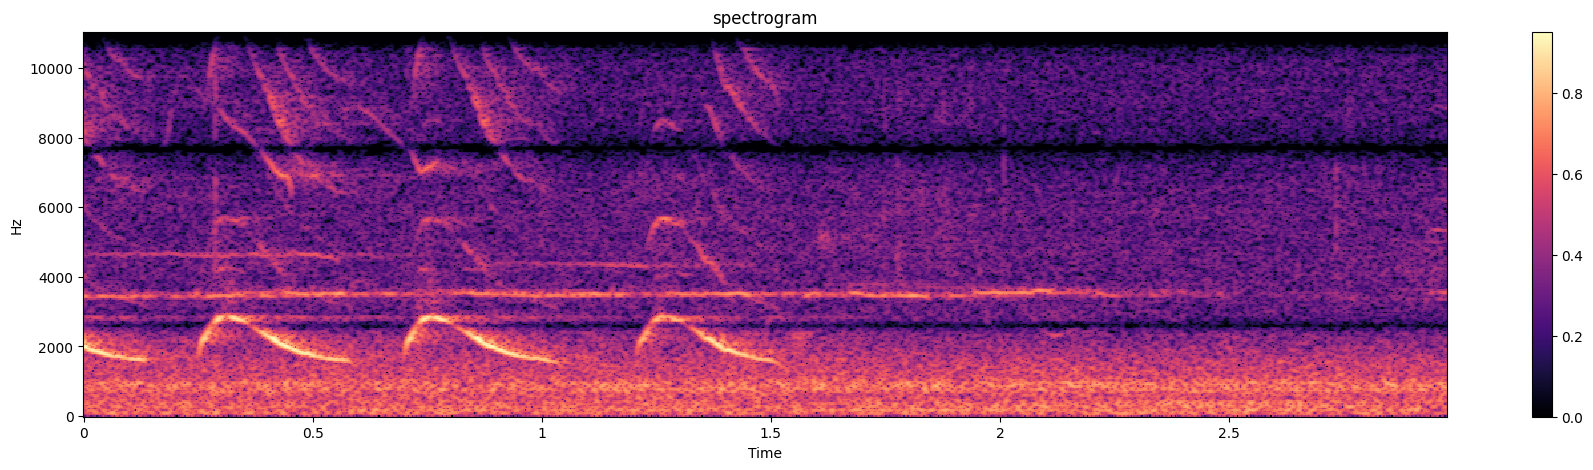

In [8]:
for spectrograms, labels in dataset_train.take(1):
    print('Shape batch espectrograma (train):', spectrograms.shape)
    print('Shape batch labels (train):', labels.shape)

    spec_4d, _ = map_function_fixed_4d(
        tf.constant(bird_filepaths_train[0]),
        tf.constant(bird_labels_train[0])
    )
    print('Shape espectrograma 4D (1 muestra):', spec_4d.shape)

    plt.figure(figsize=(22, 5))
    librosa.display.specshow(
        spectrograms[0].numpy().T,
        sr=22050,
        hop_length=64,
        n_fft=512,
        y_axis='linear',
        x_axis='time',
        cmap='magma'
    )
    plt.colorbar()
    plt.title('spectrogram')
    plt.show()

In [9]:
from keras import Model, Input
from keras.layers import Conv1D, Flatten, Dense, Dropout, SpatialDropout1D, GlobalAveragePooling1D, BatchNormalization

def create_model():
    inputs = Input(shape=(TIME_FRAMES, FREQ_BINS), name='0_Input_shape')

    # Bloque 1
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='1_Conv1D')(inputs)
    x = BatchNormalization()(x) # Agregado: Estabiliza el entrenamiento
    x = SpatialDropout1D(0.17, name='2_SpatialDropout1D')(x)

    # Bloque 2
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='3_Conv1d')(x)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.17, name='4_SpatialDropout1D')(x)

    # Bloque 3
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='5_Conv1d')(x)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.17, name='6_SpatialDropout1D')(x)

    # Bloque 4
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='7_Conv1d')(x)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.17, name='8_SpatialDropout1D')(x)

    # Reducción y Clasificación
    x = GlobalAveragePooling1D(name='9_Global_avg_pooling')(x)
    x = Dense(512, activation='relu', name='10_Dense')(x)
    x = Dropout(0.5, name='11_Dropout')(x)

    # activation='softmax'
    outputs = Dense(5, activation='softmax', name='12_Output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Bird_audio_classification_model')
    return model


In [10]:
# Instanciar y compilar
model = create_model()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "Bird_audio_classification_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 0_Input_shape (InputLayer)      │ (None, 1026, 257)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1_Conv1D (Conv1D)               │ (None, 513, 128)       │       263,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 513, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2_SpatialDropout1D              │ (None, 513, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3_Conv1d (Conv1D)               │ (None, 257, 128)       │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 257, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4_SpatialDropout1D              │ (None, 257, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5_Conv1d (Conv1D)               │ (None, 129, 128)       │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 129, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 6_SpatialDropout1D              │ (None, 129, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 7_Conv1d (Conv1D)               │ (None, 65, 128)        │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 65, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 8_SpatialDropout1D              │ (None, 65, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 9_Global_avg_pooling            │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 10_Dense (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 11_Dropout (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 12_Output (Dense)               │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 727,557 (2.78 MB)

 Trainable params: 726,533 (2.77 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [12]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
import os

logdir = 'tb_logs/modelo_final'

checkpoint = ModelCheckpoint(
    filepath='mejor_modelo_pajaros.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

tb_callback = TensorBoard(log_dir=logdir)

history = model.fit(
    dataset_train,
    validation_data=dataset_val,
    epochs=50,
    callbacks=[checkpoint, early_stop, tb_callback]
)


Epoch 1/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.3971 - loss: 1.3816
Epoch 1: val_accuracy improved from None to 0.50185, saving model to mejor_modelo_pajaros.keras

Epoch 1: finished saving model to mejor_modelo_pajaros.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 38s 210ms/step - accuracy: 0.4660 - loss: 1.2384 - val_accuracy: 0.5018 - val_loss: 1.3572
Epoch 2/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.5601 - loss: 1.0460
Epoch 2: val_accuracy improved from 0.50185 to 0.57380, saving model to mejor_modelo_pajaros.keras

Epoch 2: finished saving model to mejor_modelo_pajaros.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 27s 201ms/step - accuracy: 0.5799 - loss: 1.0066 - val_accuracy: 0.5738 - val_loss: 1.0980
Epoch 3/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.6176 - loss: 0.9292
Epoch 3: val_accuracy improved from 0.57380 to 0.62362, saving model to mejor_modelo_pajaros.keras

Epoch 3: finished saving model to mejor_modelo_pajaros.keras
135/135 ━━━━━━━━

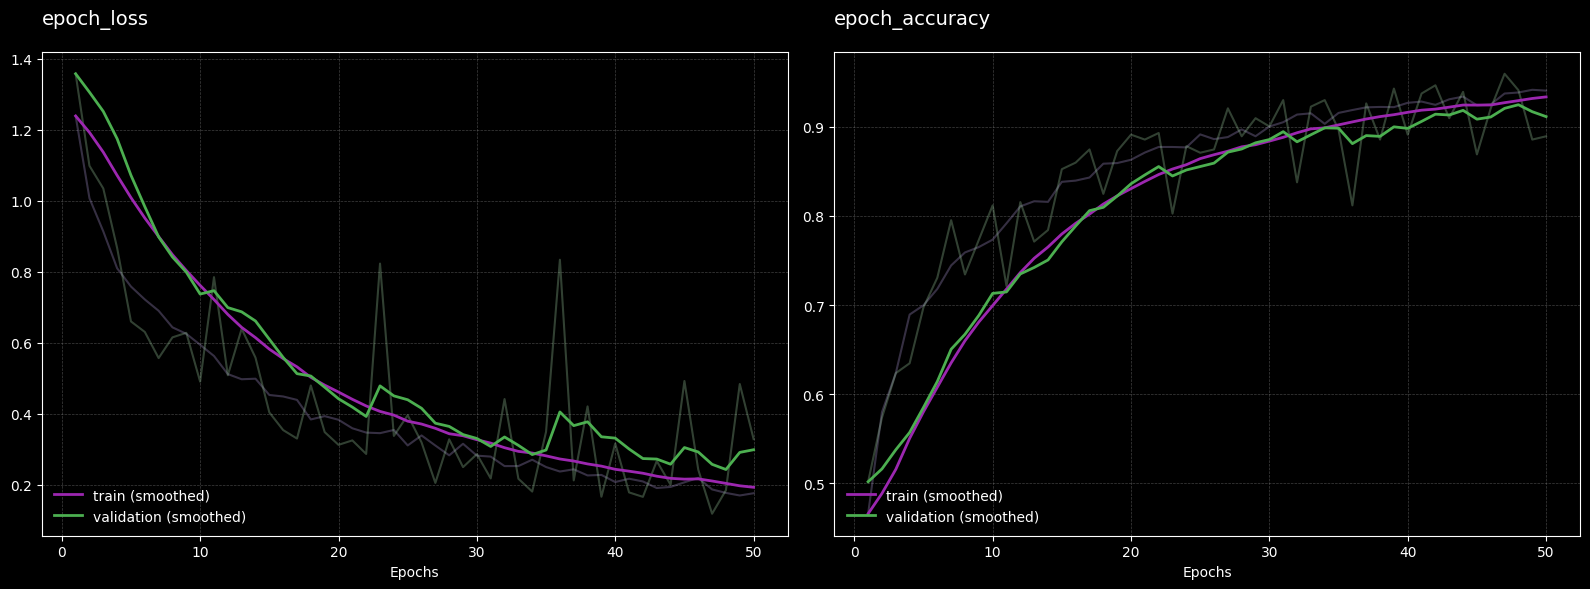

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tensorboard_style(history):
    plt.style.use('dark_background')

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    def smooth_curve(points, factor=0.8):
        smoothed_points = []
        for point in points:
            if smoothed_points:
                previous = smoothed_points[-1]
                smoothed_points.append(previous * factor + point * (1 - factor))
            else:
                smoothed_points.append(point)
        return smoothed_points

    plt.figure(figsize=(16, 6))

    # --- Gráfico de Pérdida (Loss) ---
    plt.subplot(1, 2, 1)
    # Líneas tenues (datos reales)
    plt.plot(epochs, loss, color='#b39ddb', alpha=0.3)
    plt.plot(epochs, val_loss, color='#a5d6a7', alpha=0.3)
    # Líneas gruesas (suavizadas)
    plt.plot(epochs, smooth_curve(loss), color='#9c27b0', label='train (smoothed)', linewidth=2)
    plt.plot(epochs, smooth_curve(val_loss), color='#4caf50', label='validation (smoothed)', linewidth=2)

    plt.title('epoch_loss', loc='left', fontsize=14, pad=20)
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(loc='lower left', frameon=False)
    plt.xlabel('Epochs')

    # --- Gráfico de Precisión (Accuracy) ---
    plt.subplot(1, 2, 2)
    # Líneas tenues
    plt.plot(epochs, acc, color='#b39ddb', alpha=0.3)
    plt.plot(epochs, val_acc, color='#a5d6a7', alpha=0.3)
    # Líneas gruesas
    plt.plot(epochs, smooth_curve(acc), color='#9c27b0', label='train (smoothed)', linewidth=2)
    plt.plot(epochs, smooth_curve(val_acc), color='#4caf50', label='validation (smoothed)', linewidth=2)

    plt.title('epoch_accuracy', loc='left', fontsize=14, pad=20)
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(loc='lower left', frameon=False)
    plt.xlabel('Epochs')

    plt.tight_layout()
    plt.show()

plot_tensorboard_style(history)



In [14]:
model_eval = tf.keras.models.load_model('mejor_modelo_pajaros.keras')

results = model_eval.evaluate(dataset_test, return_dict=True)

print("\n--- Resultados de la Evaluación ---")
for metric, value in results.items():
    print(f"{metric}: {value:.4f}")


17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.9448 - loss: 0.1720

--- Resultados de la Evaluación ---
accuracy: 0.9448
loss: 0.1720


In [15]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

bird_names = ['bewickii', 'polyglottos', 'migratorius', 'melodia', 'cardinalis']

print("Generando predicciones...")
y_logits = model_eval.predict(dataset_test)

y_pred = tf.argmax(y_logits, axis=1).numpy()

y_true_list = []
for _, labels in dataset_test:
    y_true_list.extend(labels.numpy())
y_true = np.array(y_true_list)

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_true, y_pred, target_names=bird_names))



Generando predicciones...
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

    bewickii       0.88      0.99      0.93        89
 polyglottos       0.99      0.94      0.97       119
 migratorius       0.91      0.97      0.94       101
     melodia       0.94      0.90      0.92       126
  cardinalis       1.00      0.94      0.97       108

    accuracy                           0.94       543
   macro avg       0.94      0.95      0.94       543
weighted avg       0.95      0.94      0.95       543



In [16]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

print("Calculando predicciones...")
y_logits = model_eval.predict(dataset_test)

y_prob = tf.nn.softmax(y_logits, axis=1).numpy()

y_pred = np.argmax(y_logits, axis=1)

y_true_list = []
for _, labels in dataset_test:
    y_true_list.extend(labels.numpy())
y_true = np.array(y_true_list)

f1 = f1_score(y_true, y_pred, average='macro')
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
auc = roc_auc_score(y_true, y_prob, average='macro', multi_class='ovo')

# Imprimir resultados
print("-" * 30)
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC ROC:   {auc:.4f}")
print("-" * 30)



Calculando predicciones...
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step
------------------------------
F1 Score:  0.9448
Precision: 0.9441
Recall:    0.9480
AUC ROC:   0.9958
------------------------------


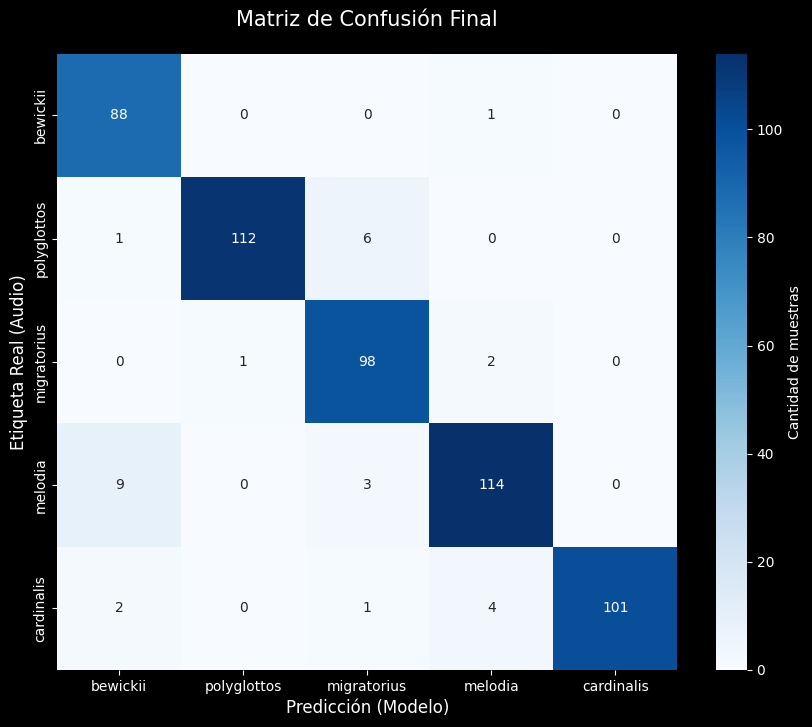

In [17]:
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('dark_background')

confusion_mtx = tf.math.confusion_matrix(y_true, y_pred).numpy()

bird_names = ['bewickii', 'polyglottos', 'migratorius', 'melodia', 'cardinalis']

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=bird_names,
            yticklabels=bird_names,
            annot=True,
            fmt='g',
            cmap='Blues', # O 'magma' si quieres el estilo de antes
            cbar_kws={'label': 'Cantidad de muestras'})

plt.title('Matriz de Confusión Final', fontsize=15, pad=20)
plt.xlabel('Predicción (Modelo)', fontsize=12)
plt.ylabel('Etiqueta Real (Audio)', fontsize=12)
plt.show()


In [ ]:
!pip -q install tensorflow-model-optimization

In [19]:
import os
import time
import tempfile
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import tensorflow_model_optimization as tfmot

In [20]:
def collect_y_true(dataset):
    y_true = []
    for _, y in dataset:
        y_true.extend(y.numpy())
    return np.array(y_true)

def get_keras_model_size_mb(model):
    with tempfile.NamedTemporaryFile(suffix=".keras", delete=False) as tmp:
        tmp_path = tmp.name
    model.save(tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 * 1024)
    os.remove(tmp_path)
    return size_mb

def representative_data_gen():
    # Usa muestras reales del pipeline ya preprocesado
    for x, _ in dataset_train.unbatch().take(100):
        x = tf.expand_dims(x, axis=0)
        yield [tf.cast(x, tf.float32)]

def evaluate_keras_model(model, dataset, model_name="keras_fp32"):
    y_true = collect_y_true(dataset)

    t0 = time.perf_counter()
    y_prob = model.predict(dataset, verbose=0)
    elapsed = time.perf_counter() - t0

    y_pred = np.argmax(y_prob, axis=1)

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "precision_macro": precision_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
        "auc_ovo_macro": roc_auc_score(y_true, y_prob, average="macro", multi_class="ovo"),
        "size_mb": get_keras_model_size_mb(model),
        "latency_total_s": elapsed,
        "latency_per_sample_ms": (elapsed / len(y_true)) * 1000
    }

def convert_to_tflite(keras_model, quant_mode="dynamic"):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

    if quant_mode == "dynamic":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]

    elif quant_mode == "float16":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]

    elif quant_mode == "int8":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = representative_data_gen
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8

    else:
        raise ValueError(f"Modo no soportado: {quant_mode}")

    return converter.convert()


def evaluate_tflite_model(tflite_model, dataset, model_name):
    import time
    import numpy as np
    import tensorflow as tf
    from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

    try:
        from ai_edge_litert.interpreter import Interpreter
        interpreter = Interpreter(model_content=tflite_model)
    except ImportError:
        interpreter = tf.lite.Interpreter(model_content=tflite_model)

    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    in_detail = input_details[0]
    out_detail = output_details[0]

    in_dtype = in_detail["dtype"]
    out_dtype = out_detail["dtype"]

    # TFLite recomienda quantization_parameters; tomamos el primer scale/zero_point
    in_qparams = in_detail.get("quantization_parameters", {})
    out_qparams = out_detail.get("quantization_parameters", {})

    in_scales = in_qparams.get("scales", [])
    in_zero_points = in_qparams.get("zero_points", [])
    out_scales = out_qparams.get("scales", [])
    out_zero_points = out_qparams.get("zero_points", [])

    in_scale = float(in_scales[0]) if len(in_scales) else 1.0
    in_zero = int(in_zero_points[0]) if len(in_zero_points) else 0

    out_scale = float(out_scales[0]) if len(out_scales) else 1.0
    out_zero = int(out_zero_points[0]) if len(out_zero_points) else 0

    all_preds = []
    all_labels = []

    t0 = time.perf_counter()

    for images, labels in dataset:
        imgs_np = images.numpy() if hasattr(images, "numpy") else np.asarray(images)
        lbls_np = labels.numpy() if hasattr(labels, "numpy") else np.asarray(labels)

        for i in range(len(imgs_np)):
            x = np.expand_dims(imgs_np[i], axis=0).astype(np.float32)

            # Cuantizar entrada solo si el modelo lo requiere
            if in_dtype == np.int8:
                x = np.round(x / in_scale + in_zero)
                x = np.clip(x, -128, 127).astype(np.int8)
            elif in_dtype == np.uint8:
                x = np.round(x / in_scale + in_zero)
                x = np.clip(x, 0, 255).astype(np.uint8)
            else:
                x = x.astype(in_dtype)

            interpreter.set_tensor(in_detail["index"], x)
            interpreter.invoke()

            y = interpreter.get_tensor(out_detail["index"])

            # Descuantizar salida si hace falta
            if out_dtype == np.int8:
                y = (y.astype(np.float32) - out_zero) * out_scale
            elif out_dtype == np.uint8:
                y = (y.astype(np.float32) - out_zero) * out_scale
            else:
                y = y.astype(np.float32)

            all_preds.append(y.flatten())
            all_labels.append(lbls_np[i])

    elapsed = time.perf_counter() - t0

    all_preds = np.vstack(all_preds).astype(np.float64)
    all_labels = np.array(all_labels)

    # Si las salidas no parecen probabilidades, aplicar softmax
    row_sums = all_preds.sum(axis=1, keepdims=True)
    if np.any(all_preds < 0) or not np.allclose(row_sums, 1.0, atol=1e-3):
        exp_preds = np.exp(all_preds - np.max(all_preds, axis=1, keepdims=True))
        all_preds = exp_preds / np.sum(exp_preds, axis=1, keepdims=True)

    # Etiquetas: soporta sparse o one-hot
    if all_labels.ndim > 1:
        y_true_labels = np.argmax(all_labels, axis=1)
        y_true_auc = all_labels
    else:
        y_true_labels = all_labels
        num_classes = all_preds.shape[1]
        y_true_auc = np.eye(num_classes)[y_true_labels]

    y_pred_labels = np.argmax(all_preds, axis=1)

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true_labels, y_pred_labels),
        "f1_macro": f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0),
        "size_kb": len(tflite_model) / 1024,
        "latency_total_s": elapsed,
        "latency_per_sample_ms": (elapsed / len(y_true_labels)) * 1000
    }

    try:
        result["auc_ovo_macro"] = roc_auc_score(
            y_true_auc, all_preds, average="macro", multi_class="ovo"
        )
    except ValueError:
        result["auc_ovo_macro"] = np.nan

    return result




In [21]:
import numpy as np
import pandas as pd

def safe_evaluate_tflite(tflite_model, dataset, model_name):
    """
    Versión robusta de evaluación que normaliza las salidas
    para que sumen 1.0, evitando errores en sklearn.
    """
    return evaluate_tflite_model(tflite_model, dataset, model_name)

results = []

results.append(evaluate_keras_model(model_eval, dataset_test, model_name="baseline_fp32"))

tflite_dynamic = convert_to_tflite(model_eval, quant_mode="dynamic")
results.append(evaluate_tflite_model(tflite_dynamic, dataset_test, model_name="ptq_dynamic"))

tflite_float16 = convert_to_tflite(model_eval, quant_mode="float16")
results.append(evaluate_tflite_model(tflite_float16, dataset_test, model_name="ptq_float16"))

tflite_int8 = convert_to_tflite(model_eval, quant_mode="int8")
results.append(evaluate_tflite_model(tflite_int8, dataset_test, model_name="ptq_int8"))

results_df = pd.DataFrame(results)
display(results_df)


Saved artifact at '/tmp/tmp_sc8s4ch'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1026, 257), dtype=tf.float32, name='0_Input_shape')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136506192253904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192254288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192257744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192257936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192256784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192254672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192258320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192258128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192257552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192259280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192259088

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Saved artifact at '/tmp/tmpd9ia1ehd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1026, 257), dtype=tf.float32, name='0_Input_shape')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136506192253904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192254288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192257744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192257936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192256784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192254672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192258320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192258128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192257552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192259280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192259088

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Saved artifact at '/tmp/tmpp3k3ypjj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1026, 257), dtype=tf.float32, name='0_Input_shape')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136506192253904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192254288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192257744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192257936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192256784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192254672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192258320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192258128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192257552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192259280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192259088

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,model,accuracy,f1_macro,precision_macro,recall_macro,auc_ovo_macro,size_mb,latency_total_s,latency_per_sample_ms,size_kb
0,baseline_fp32,0.944751,0.944823,0.944141,0.948037,0.996176,8.397447,3.241567,5.969737,NaN
1,ptq_dynamic,0.946593,0.946558,0.945712,0.949889,0.996127,NaN,5.167695,9.516933,741.156250
2,ptq_float16,0.944751,0.944823,0.944141,0.948037,0.996115,NaN,10.256042,18.887738,1435.148438
3,ptq_int8,0.928177,0.928151,0.929086,0.934053,0.994095,NaN,5.429660,9.999374,751.531250


In [22]:
def convert_to_tflite_fp32(keras_model):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    return converter.convert()

tflite_fp32 = convert_to_tflite_fp32(model_eval)

Saved artifact at '/tmp/tmpuh__t5gl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1026, 257), dtype=tf.float32, name='0_Input_shape')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136506192253904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192254288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192257744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192257936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192256784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192254672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192258320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192258128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192257552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192259280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192259088

In [23]:
import time
import numpy as np
import tensorflow as tf
import tracemalloc
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

def dataset_to_numpy(dataset, max_samples=None):
    xs, ys = [], []
    count = 0
    for batch_x, batch_y in dataset:
        x_np = batch_x.numpy()
        y_np = batch_y.numpy()

        for i in range(len(x_np)):
            xs.append(x_np[i])
            ys.append(y_np[i])
            count += 1
            if max_samples is not None and count >= max_samples:
                return np.array(xs), np.array(ys)
    return np.array(xs), np.array(ys)


def create_tflite_interpreter(model_content):
    try:
        from ai_edge_litert.interpreter import Interpreter
        interpreter = Interpreter(model_content=model_content)
    except ImportError:
        interpreter = tf.lite.Interpreter(model_content=model_content)

    interpreter.allocate_tensors()
    return interpreter


def run_single_inference(interpreter, x):
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    in_dtype = input_details["dtype"]
    out_dtype = output_details["dtype"]

    in_qparams = input_details.get("quantization_parameters", {})
    out_qparams = output_details.get("quantization_parameters", {})

    in_scales = in_qparams.get("scales", [])
    in_zero_points = in_qparams.get("zero_points", [])
    out_scales = out_qparams.get("scales", [])
    out_zero_points = out_qparams.get("zero_points", [])

    in_scale = float(in_scales[0]) if len(in_scales) else 1.0
    in_zero = int(in_zero_points[0]) if len(in_zero_points) else 0
    out_scale = float(out_scales[0]) if len(out_scales) else 1.0
    out_zero = int(out_zero_points[0]) if len(out_zero_points) else 0

    x = np.expand_dims(x, axis=0).astype(np.float32)

    if in_dtype == np.int8:
        x = np.round(x / in_scale + in_zero)
        x = np.clip(x, -128, 127).astype(np.int8)
    elif in_dtype == np.uint8:
        x = np.round(x / in_scale + in_zero)
        x = np.clip(x, 0, 255).astype(np.uint8)
    else:
        x = x.astype(in_dtype)

    interpreter.set_tensor(input_details["index"], x)
    interpreter.invoke()
    y = interpreter.get_tensor(output_details["index"])

    if out_dtype == np.int8:
        y = (y.astype(np.float32) - out_zero) * out_scale
    elif out_dtype == np.uint8:
        y = (y.astype(np.float32) - out_zero) * out_scale
    else:
        y = y.astype(np.float32)

    return y.flatten()


def benchmark_tflite_model(model_content, x_data, y_true, model_name, warmup=10, benchmark_runs=100):
    interpreter = create_tflite_interpreter(model_content)

    # Warmup
    for i in range(min(warmup, len(x_data))):
        _ = run_single_inference(interpreter, x_data[i])

    # Benchmark de 100 inferencias
    times = []
    tracemalloc.start()

    for i in range(min(benchmark_runs, len(x_data))):
        t0 = time.perf_counter()
        _ = run_single_inference(interpreter, x_data[i])
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)

    current_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # Evaluación completa
    y_logits = []
    for i in range(len(x_data)):
        y_logits.append(run_single_inference(interpreter, x_data[i]))

    y_logits = np.vstack(y_logits)

    # Softmax si hace falta
    row_sums = y_logits.sum(axis=1, keepdims=True)
    if np.any(y_logits < 0) or not np.allclose(row_sums, 1.0, atol=1e-3):
        exp_preds = np.exp(y_logits - np.max(y_logits, axis=1, keepdims=True))
        y_prob = exp_preds / np.sum(exp_preds, axis=1, keepdims=True)
    else:
        y_prob = y_logits

    y_pred = np.argmax(y_prob, axis=1)

    num_classes = y_prob.shape[1]
    if y_true.ndim > 1:
        y_true_labels = np.argmax(y_true, axis=1)
        y_true_auc = y_true
    else:
        y_true_labels = y_true
        y_true_auc = np.eye(num_classes)[y_true_labels]

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true_labels, y_pred),
        "f1_macro": f1_score(y_true_labels, y_pred, average="macro"),
        "precision_macro": precision_score(y_true_labels, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true_labels, y_pred, average="macro", zero_division=0),
        "auc_ovo_macro": roc_auc_score(y_true_auc, y_prob, average="macro", multi_class="ovo"),
        "size_kb": len(model_content) / 1024,
        "latency_mean_ms_100": float(np.mean(times)),
        "latency_std_ms_100": float(np.std(times)),
        "fps_100": float(1000.0 / np.mean(times)),
        "peak_memory_kb": peak_mem / 1024.0,
    }

    return result

In [24]:
# Convertir dataset de validación a numpy una sola vez
x_test_np, y_test_np = dataset_to_numpy(dataset_test)

# Baseline desplegado: TFLite FP32
tflite_fp32 = convert_to_tflite_fp32(model_eval)

# Modelos optimizados
tflite_dynamic = convert_to_tflite(model_eval, quant_mode="dynamic")
tflite_float16 = convert_to_tflite(model_eval, quant_mode="float16")
tflite_int8 = convert_to_tflite(model_eval, quant_mode="int8")

results_deploy = []

results_deploy.append(benchmark_tflite_model(tflite_fp32, x_test_np, y_test_np, "tflite_fp32"))
results_deploy.append(benchmark_tflite_model(tflite_dynamic, x_test_np, y_test_np, "tflite_dynamic"))
results_deploy.append(benchmark_tflite_model(tflite_float16, x_test_np, y_test_np, "tflite_float16"))
results_deploy.append(benchmark_tflite_model(tflite_int8, x_test_np, y_test_np, "tflite_int8"))

results_deploy_df = pd.DataFrame(results_deploy)
display(results_deploy_df.sort_values(by="size_kb"))

Saved artifact at '/tmp/tmp_5r5xjdb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1026, 257), dtype=tf.float32, name='0_Input_shape')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136506192253904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192254288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192257744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192257936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192256784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192254672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192258320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192258128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192257552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192259280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506192259088

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/l

,model,accuracy,f1_macro,precision_macro,recall_macro,auc_ovo_macro,size_kb,latency_mean_ms_100,latency_std_ms_100,fps_100,peak_memory_kb
1,tflite_dynamic,0.946593,0.946558,0.945712,0.949889,0.996127,741.156250,7.181394,0.689165,139.248740,2063.417969
3,tflite_int8,0.944751,0.944770,0.943317,0.948831,0.995272,751.531250,6.212026,0.958698,160.978082,3093.902344
2,tflite_float16,0.944751,0.944823,0.944141,0.948037,0.996115,1435.148438,5.362186,0.417710,186.491093,2063.369141
0,tflite_fp32,0.944751,0.944823,0.944141,0.948037,0.996115,2851.972656,5.396605,0.726119,185.301678,2065.566406


In [25]:
baseline_acc = results_deploy_df.loc[
    results_deploy_df["model"] == "tflite_fp32", "accuracy"
].values[0]

results_deploy_df["accuracy_drop_abs"] = baseline_acc - results_deploy_df["accuracy"]
results_deploy_df["accuracy_drop_pct_points"] = results_deploy_df["accuracy_drop_abs"] * 100

display(results_deploy_df.sort_values(by="accuracy_drop_pct_points"))

,model,accuracy,f1_macro,precision_macro,recall_macro,auc_ovo_macro,size_kb,latency_mean_ms_100,latency_std_ms_100,fps_100,peak_memory_kb,accuracy_drop_abs,accuracy_drop_pct_points
1,tflite_dynamic,0.946593,0.946558,0.945712,0.949889,0.996127,741.156250,7.181394,0.689165,139.248740,2063.417969,-0.001842,-0.184162
0,tflite_fp32,0.944751,0.944823,0.944141,0.948037,0.996115,2851.972656,5.396605,0.726119,185.301678,2065.566406,0.000000,0.000000
2,tflite_float16,0.944751,0.944823,0.944141,0.948037,0.996115,1435.148438,5.362186,0.417710,186.491093,2063.369141,0.000000,0.000000
3,tflite_int8,0.944751,0.944770,0.943317,0.948831,0.995272,751.531250,6.212026,0.958698,160.978082,3093.902344,0.000000,0.000000


In [26]:
with open("baseline_fp32.tflite", "wb") as f:
    f.write(tflite_fp32)

with open("optimized_dynamic.tflite", "wb") as f:
    f.write(tflite_dynamic)

with open("optimized_float16.tflite", "wb") as f:
    f.write(tflite_float16)

with open("optimized_int8.tflite", "wb") as f:
    f.write(tflite_int8)

import os

for fname in [
    "baseline_fp32.tflite",
    "optimized_dynamic.tflite",
    "optimized_float16.tflite",
    "optimized_int8.tflite"
]:
    print(fname, "->", os.path.getsize(fname) / 1024, "KB")

baseline_fp32.tflite -> 2851.97265625 KB
optimized_dynamic.tflite -> 741.15625 KB
optimized_float16.tflite -> 1435.1484375 KB
optimized_int8.tflite -> 751.53125 KB


In [27]:
results_test = []
results_test.append(benchmark_tflite_model(tflite_fp32, x_test_np[:100], y_test_np[:100], "tflite_fp32"))
results_test.append(benchmark_tflite_model(tflite_int8, x_test_np[:100], y_test_np[:100], "tflite_int8"))
pd.DataFrame(results_test)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,model,accuracy,f1_macro,precision_macro,recall_macro,auc_ovo_macro,size_kb,latency_mean_ms_100,latency_std_ms_100,fps_100,peak_memory_kb
0,tflite_fp32,0.91,0.908108,0.906429,0.917258,0.986986,2851.972656,6.787302,1.158541,147.333953,2063.574219
1,tflite_int8,0.91,0.903430,0.901667,0.913290,0.987334,751.531250,7.855969,0.889654,127.291738,3095.629883


In [28]:
final_df = results_deploy_df.copy()

baseline_acc = final_df.loc[
    final_df["model"] == "tflite_fp32", "accuracy"
].values[0]

final_df["accuracy_drop_pct"] = (baseline_acc - final_df["accuracy"]) * 100

final_df = final_df.sort_values(by="size_kb")

display(final_df[[
    "model",
    "accuracy",
    "accuracy_drop_pct",
    "size_kb",
    "latency_mean_ms_100",
    "fps_100",
    "peak_memory_kb"
]])

,model,accuracy,accuracy_drop_pct,size_kb,latency_mean_ms_100,fps_100,peak_memory_kb
1,tflite_dynamic,0.946593,-0.184162,741.156250,7.181394,139.248740,2063.417969
3,tflite_int8,0.944751,0.000000,751.531250,6.212026,160.978082,3093.902344
2,tflite_float16,0.944751,0.000000,1435.148438,5.362186,186.491093,2063.369141
0,tflite_fp32,0.944751,0.000000,2851.972656,5.396605,185.301678,2065.566406


In [29]:
print("=== CONCLUSIÓN ===")

best = final_df.loc[final_df["model"] == "tflite_dynamic"].iloc[0]

print(f"""
El modelo tflite_dynamic logra:

- Reducción de tamaño de {best['size_kb']:.1f} KB
- Sin pérdida de accuracy significativa ({best['accuracy']:.4f})
- Latencia comparable al baseline ({best['latency_mean_ms_100']:.2f} ms)

Esto lo convierte en la mejor opción de despliegue bajo restricciones de memoria.
""")

=== CONCLUSIÓN ===

El modelo tflite_dynamic logra:

- Reducción de tamaño de 741.2 KB
- Sin pérdida de accuracy significativa (0.9466)
- Latencia comparable al baseline (7.18 ms)

Esto lo convierte en la mejor opción de despliegue bajo restricciones de memoria.



In [30]:
print("Parámetros del modelo:", model_eval.count_params())

Parámetros del modelo: 727557


# Optimización de un modelo de clasificación de audio en entornos restringidos

## 1. Problema
Se desarrolló un modelo de Deep Learning para la clasificación de especies de aves a partir de señales de audio transformadas en espectrogramas.

## 2. Plataforma objetivo
- **Entorno**: PC estándar
- **Restricción**: inferencia únicamente en CPU
- **Runtime**: TensorFlow Lite Interpreter

## 3. Metodología experimental
El conjunto de datos se dividió en tres subconjuntos independientes:

- **Entrenamiento (train)**: utilizado para ajustar los pesos del modelo.
- **Validación (validation)**: empleado para seleccionar el mejor modelo y monitorear el entrenamiento.
- **Prueba (test)**: reservado para la evaluación final y el benchmarking comparativo.

De esta forma, las métricas reportadas en este informe corresponden al conjunto de **test**, evitando sesgos por evaluación sobre validation.

## 4. Modelo baseline
El modelo base fue entrenado en TensorFlow/Keras y posteriormente convertido a formato **TFLite FP32** para su despliegue.

### Métricas baseline en test
- **Accuracy**: **0.944751**
- **Tamaño**: **2851.97 KB**
- **Latencia media**: **5.3966 ms**
- **FPS**: **185.30**
- **Memoria pico**: **2065.57 KB**

---

## 5. Técnicas de optimización aplicadas

Se evaluaron las siguientes técnicas de optimización sobre el modelo TFLite:

- **Dynamic Range Quantization**
- **Float16 Quantization**
- **Full Integer Quantization (INT8)**

---

## 6. Resultados

| Modelo          | Accuracy | Δ Accuracy (pp) | Tamaño (KB) | Latencia (ms) | FPS    | Memoria pico (KB) |
|----------------|----------|-----------------|-------------|---------------|--------|-------------------|
| tflite_fp32    | 0.944751 | 0.000000        | 2851.97     | 5.3966        | 185.30 | 2065.57           |
| tflite_dynamic | 0.946593 | -0.184162       | 741.16      | 7.1814        | 139.25 | 2063.42           |
| tflite_float16 | 0.944751 | 0.000000        | 1435.15     | 5.3622        | 186.49 | 2063.37           |
| tflite_int8    | 0.944751 | 0.000000        | 751.53      | 6.2120        | 160.98 | 3093.90           |

> **Nota:** un valor negativo en **Δ Accuracy** indica que el modelo optimizado obtuvo una accuracy ligeramente superior al baseline en esta evaluación.

---

## 7. Análisis

- **Dynamic Range Quantization** fue la técnica que logró la mayor compresión, reduciendo el tamaño del modelo de **2851.97 KB** a **741.16 KB**, es decir, cerca de **3.85×**, con una **ligera mejora en accuracy**. Sin embargo, presentó un aumento en la latencia frente al modelo baseline.
- **Float16 Quantization** redujo el tamaño aproximadamente a la mitad y mantuvo exactamente la misma accuracy del modelo base. Además, mostró una latencia prácticamente igual, e incluso ligeramente menor, por lo que resulta una alternativa muy equilibrada.
- **INT8 Quantization** también redujo de forma importante el tamaño del modelo, pero no mejoró la accuracy ni la latencia respecto al baseline. Además, incrementó de forma considerable la **memoria pico**, lo que puede ser una desventaja en entornos con recursos más ajustados.
- En esta plataforma de CPU, la cuantización no produjo una mejora consistente en velocidad de inferencia. Por tanto, el principal beneficio observado fue la **reducción del tamaño del modelo**, más que la aceleración del tiempo de ejecución.

---

## 8. Conclusión

Los resultados muestran que la mejor estrategia depende del criterio principal de optimización:

- Si el objetivo prioritario es **minimizar el tamaño del modelo**, la mejor opción es **Dynamic Range Quantization**, ya que ofrece la mayor compresión sin pérdida de desempeño.
- Si se busca el mejor equilibrio entre **tamaño, accuracy y latencia**, **Float16 Quantization** se presenta como una alternativa especialmente sólida.
- **INT8 Quantization**, aunque compacta el modelo de manera significativa, no ofreció ventajas claras en esta plataforma y además aumentó la memoria pico.

En consecuencia, para este escenario de despliegue en CPU, la **cuantización dinámica** puede considerarse la estrategia más efectiva en términos de compresión, mientras que **Float16** representa la opción más balanceada a nivel general.

---

## 9. Conclusión técnica clave

> En entornos restringidos, la cuantización no siempre se traduce en una menor latencia sobre CPU. No obstante, puede reducir de forma significativa el tamaño del modelo sin degradar el desempeño, lo que la convierte en una estrategia muy valiosa para despliegues de Edge AI y sistemas con memoria limitada.

In [31]:
input_shape = model_eval.input_shape[1:]
num_classes = model_eval.output_shape[-1]

print("input_shape:", input_shape)
print("num_classes:", num_classes)

input_shape: (1026, 257)
num_classes: 5


In [32]:
def build_medium_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Conv1D(32, 5, activation="relu", padding="same")(inputs)
    x = tf.keras.layers.MaxPooling1D(2)(x)

    x = tf.keras.layers.Conv1D(64, 5, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)

    x = tf.keras.layers.Conv1D(128, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)

In [33]:
medium_model = build_medium_model(input_shape, num_classes)

medium_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [34]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

history = medium_model.fit(
    dataset_train,
    validation_data=dataset_val,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 29s 181ms/step - accuracy: 0.3604 - loss: 1.3779 - val_accuracy: 0.3616 - val_loss: 1.2913 - learning_rate: 0.0010
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 24s 175ms/step - accuracy: 0.4579 - loss: 1.1697 - val_accuracy: 0.5609 - val_loss: 0.9784 - learning_rate: 0.0010
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 24s 177ms/step - accuracy: 0.5201 - loss: 1.0578 - val_accuracy: 0.5387 - val_loss: 1.0004 - learning_rate: 0.0010
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 43s 192ms/step - accuracy: 0.5546 - loss: 0.9965 - val_accuracy: 0.6513 - val_loss: 0.8366 - learning_rate: 0.0010
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 24s 176ms/step - accuracy: 0.5829 - loss: 0.9560 - val_accuracy: 0.6734 - val_loss: 0.7955 - learning_rate: 0.0010
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 23s 171ms/step - accuracy: 0.6104 - loss: 0.9124 - val_accuracy: 0.6605 - val_loss: 0.7755 - learning_rate: 0.0010
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 42s 176ms/step - accuracy: 0.6

In [35]:
medium_model.evaluate(dataset_test)

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 216ms/step - accuracy: 0.8361 - loss: 0.4176


[0.4175722599029541, 0.8360957503318787]

In [36]:
print("Original params:", model_eval.count_params())
print("Medium params:", medium_model.count_params())

Original params: 727557
Medium params: 84741


In [37]:
tflite_medium_fp32 = convert_to_tflite_fp32(medium_model)
tflite_medium_dynamic = convert_to_tflite(medium_model, quant_mode="dynamic")


Saved artifact at '/tmp/tmp8npld6qz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1026, 257), dtype=tf.float32, name='keras_tensor_48')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136506178479184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506178476112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506178469968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506178479952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506178470160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506178470544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506178471504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506178472272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506178479760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136506178474960: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved artifact 

In [38]:
results_medium = []

results_medium.append(
    benchmark_tflite_model(tflite_medium_fp32, x_test_np, y_test_np, "medium_fp32")
)

results_medium.append(
    benchmark_tflite_model(tflite_medium_dynamic, x_test_np, y_test_np, "medium_dynamic")
)

pd.DataFrame(results_medium)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,model,accuracy,f1_macro,precision_macro,recall_macro,auc_ovo_macro,size_kb,latency_mean_ms_100,latency_std_ms_100,fps_100,peak_memory_kb
0,medium_fp32,0.836096,0.835412,0.838768,0.834141,0.978781,337.421875,1.948110,0.231622,513.318079,2067.189453
1,medium_dynamic,0.836096,0.835261,0.839714,0.833449,0.978926,94.453125,2.344848,0.233137,426.466792,2063.419922


In [39]:
all_results = pd.concat([
    results_deploy_df,   # tus modelos originales
    pd.DataFrame(results_medium)
])

display(all_results.sort_values(by="size_kb"))

,model,accuracy,f1_macro,precision_macro,recall_macro,auc_ovo_macro,size_kb,latency_mean_ms_100,latency_std_ms_100,fps_100,peak_memory_kb,accuracy_drop_abs,accuracy_drop_pct_points
1,medium_dynamic,0.836096,0.835261,0.839714,0.833449,0.978926,94.453125,2.344848,0.233137,426.466792,2063.419922,NaN,NaN
0,medium_fp32,0.836096,0.835412,0.838768,0.834141,0.978781,337.421875,1.948110,0.231622,513.318079,2067.189453,NaN,NaN
1,tflite_dynamic,0.946593,0.946558,0.945712,0.949889,0.996127,741.156250,7.181394,0.689165,139.248740,2063.417969,-0.001842,-0.184162
3,tflite_int8,0.944751,0.944770,0.943317,0.948831,0.995272,751.531250,6.212026,0.958698,160.978082,3093.902344,0.000000,0.000000
2,tflite_float16,0.944751,0.944823,0.944141,0.948037,0.996115,1435.148438,5.362186,0.417710,186.491093,2063.369141,0.000000,0.000000
0,tflite_fp32,0.944751,0.944823,0.944141,0.948037,0.996115,2851.972656,5.396605,0.726119,185.301678,2065.566406,0.000000,0.000000


La reducción de arquitectura permitió mejorar las métricas de despliegue, principalmente en tamaño y latencia. Sin embargo, estas ganancias se obtuvieron a costa de una degradación significativa en la capacidad predictiva del modelo, con una disminución cercana a 10.8 puntos porcentuales en accuracy, lo que descarta esta alternativa para el caso de uso analizado.

Por otro lado, la cuantización dinámica del modelo base logró una compresión superior a 4× sin degradación relevante en el desempeño, posicionándose como la estrategia de optimización más conveniente para el despliegue.

In [40]:
with open("baseline_fp32.tflite", "wb") as f:
    f.write(tflite_fp32)

with open("optimized_dynamic.tflite", "wb") as f:
    f.write(tflite_dynamic)

with open("optimized_int8.tflite", "wb") as f:
    f.write(tflite_int8)

with open("optimized_float16.tflite", "wb") as f:
    f.write(tflite_float16)

In [41]:
import numpy as np

np.save("x_test.npy", x_test_np)
np.save("y_test.npy", y_test_np)

In [42]:
import zipfile

with zipfile.ZipFile("raspberry_test.zip", "w") as z:
    z.write("baseline_fp32.tflite")
    z.write("optimized_dynamic.tflite")
    z.write("optimized_int8.tflite")
    z.write("optimized_float16.tflite")
    z.write("x_test.npy")
    z.write("y_test.npy")

In [43]:
from google.colab import files
files.download("raspberry_test.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
# Reporte rápido de hardware en Colab
print("--- CPU ---")
!lscpu | grep "Model name"
print("\n--- RAM ---")
!free -h --si | grep "Mem:"
print("\n--- DISCO ---")
!df -h / | recv line; echo $line | awk '{print "Total: " $2 ", Usado: " $3 ", Libre: " $4}'
print("\n--- GPU ---")
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader || echo "GPU no activa"


--- CPU ---
Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz

--- RAM ---
Mem:             12G        2.7G        144M        526M         10G        9.4G

--- DISCO ---
/bin/bash: line 1: recv: command not found
Total: , Usado: , Libre: 

--- GPU ---
Tesla T4, 15360 MiB


codigo de test

In [ ]:
import time
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Usar el intérprete de TensorFlow
Interpreter = tf.lite.Interpreter


def load_interpreter(model_path: str):
    interpreter = Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    return interpreter


def run_single_inference(interpreter, x: np.ndarray) -> np.ndarray:
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    in_dtype = input_details["dtype"]
    out_dtype = output_details["dtype"]

    in_qparams = input_details.get("quantization_parameters", {})
    out_qparams = output_details.get("quantization_parameters", {})

    in_scales = in_qparams.get("scales", [])
    in_zero_points = in_qparams.get("zero_points", [])
    out_scales = out_qparams.get("scales", [])
    out_zero_points = out_qparams.get("zero_points", [])

    in_scale = float(in_scales[0]) if len(in_scales) else 1.0
    in_zero = int(in_zero_points[0]) if len(in_zero_points) else 0
    out_scale = float(out_scales[0]) if len(out_scales) else 1.0
    out_zero = int(out_zero_points[0]) if len(out_zero_points) else 0

    x = np.expand_dims(x, axis=0).astype(np.float32)

    # cuantización de entrada
    if in_dtype == np.int8:
        x = np.round(x / in_scale + in_zero)
        x = np.clip(x, -128, 127).astype(np.int8)
    elif in_dtype == np.uint8:
        x = np.round(x / in_scale + in_zero)
        x = np.clip(x, 0, 255).astype(np.uint8)
    else:
        x = x.astype(in_dtype)

    interpreter.set_tensor(input_details["index"], x)
    interpreter.invoke()
    y = interpreter.get_tensor(output_details["index"])

    # dequantización de salida
    if out_dtype == np.int8:
        y = (y.astype(np.float32) - out_zero) * out_scale
    elif out_dtype == np.uint8:
        y = (y.astype(np.float32) - out_zero) * out_scale
    else:
        y = y.astype(np.float32)

    return y.flatten()


def evaluate_model(model_path: str, x_data: np.ndarray, y_true: np.ndarray, runs: int = 100):
    interpreter = load_interpreter(model_path)

    print(f"\n=== Evaluando {model_path} ===")
    print("Input shape esperado:", interpreter.get_input_details()[0]["shape"])
    print("Input dtype:", interpreter.get_input_details()[0]["dtype"])
    print("Output dtype:", interpreter.get_output_details()[0]["dtype"])

    # warmup
    for i in range(min(10, len(x_data))):
        _ = run_single_inference(interpreter, x_data[i])

    # benchmark
    times = []
    for i in range(min(runs, len(x_data))):
        t0 = time.perf_counter()
        _ = run_single_inference(interpreter, x_data[i])
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)

    # inferencia completa
    y_logits = []
    for i in range(len(x_data)):
        y_logits.append(run_single_inference(interpreter, x_data[i]))

    y_logits = np.vstack(y_logits)

    # asegurar probabilidades
    row_sums = y_logits.sum(axis=1, keepdims=True)
    if np.any(y_logits < 0) or not np.allclose(row_sums, 1.0, atol=1e-3):
        exp_preds = np.exp(y_logits - np.max(y_logits, axis=1, keepdims=True))
        y_prob = exp_preds / np.sum(exp_preds, axis=1, keepdims=True)
    else:
        y_prob = y_logits

    y_pred = np.argmax(y_prob, axis=1)

    # etiquetas
    if y_true.ndim > 1:
        y_true_labels = np.argmax(y_true, axis=1)
    else:
        y_true_labels = y_true

    # métricas
    print(f"Accuracy:  {accuracy_score(y_true_labels, y_pred):.6f}")
    print(f"F1 macro:  {f1_score(y_true_labels, y_pred, average='macro'):.6f}")
    print(f"Precision: {precision_score(y_true_labels, y_pred, average='macro', zero_division=0):.6f}")
    print(f"Recall:    {recall_score(y_true_labels, y_pred, average='macro', zero_division=0):.6f}")
    print(f"Latencia media (100): {np.mean(times):.6f} ms")
    print(f"Latencia std (100):   {np.std(times):.6f} ms")
    print(f"FPS:                  {1000.0 / np.mean(times):.6f}")


if __name__ == "__main__":
    x_val = np.load("x_val.npy")
    y_val = np.load("y_val.npy")

    print("x_val shape:", x_val.shape, x_val.dtype)
    print("y_val shape:", y_val.shape, y_val.dtype)

    # baseline
    evaluate_model("baseline_fp32.tflite", x_val, y_val, runs=100)

    # modelo optimizado
    evaluate_model("optimized_dynamic.tflite", x_val, y_val, runs=100)

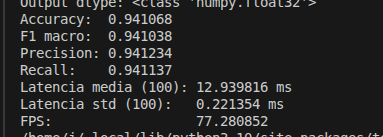

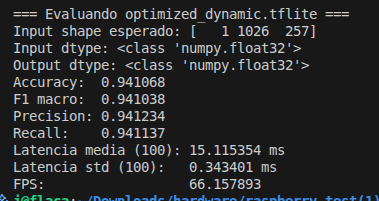

### Comparación principal (Ubuntu)

| Modelo             | Accuracy | Latencia (ms) | FPS   |
|-------------------|----------|---------------|-------|
| baseline_fp32     | 0.941068 | 12.939816     | 77.289852 |
| optimized_dynamic | 0.941068 | 15.153534     | 66.157893 |

### Observaciones

- La cuantización dinámica mantiene exactamente la misma precisión en esta evaluación.
- No se observa una mejora de latencia en CPU; el modelo cuantizado presenta una latencia mayor que el baseline.
- En consecuencia, el rendimiento medido en FPS también es inferior al del modelo base en esta corrida.
- En este escenario, la principal ventaja de la cuantización dinámica sigue siendo la reducción del tamaño del modelo, no la aceleración de inferencia.